# Question 3 - Traffic Flow Time Series

This notebook estimates incoming traffic flow from the fine-tuned YOLOv8 detector, converts the detections into a frame-level time series, and forecasts future flow using SARIMAX/ARIMA. Because the dataset is stored as overlapping aerial crops instead of a continuous full-frame video, the counting method uses manually defined incoming-road regions of interest (ROIs) rather than fragile line-crossing tracking.


## 1. Setup

The detector is the fine-tuned `best.pt` produced in Question 2. Frame numbers and crop offsets are parsed from filenames such as `frame_0010_y440_x512...jpg`, then each crop detection is moved back into global 1920x1080 intersection coordinates.


In [1]:
import os
import re
import math
import warnings
from pathlib import Path
from collections import defaultdict

os.environ.setdefault("YOLO_CONFIG_DIR", str(Path.cwd().parent / ".ultralytics"))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from ultralytics import YOLO

warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd()
TRAFFIC_ROOT = DATA_DIR / "TrafficProject"
IMAGE_DIR = TRAFFIC_ROOT / "train"
RESULTS_DIR = TRAFFIC_ROOT / "results"
TASK3_DIR = RESULTS_DIR / "task3_forecasts"
MODEL_PATH = RESULTS_DIR / "fine_tuned_artifacts" / "weights" / "best.pt"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
TASK3_DIR.mkdir(parents=True, exist_ok=True)

assert MODEL_PATH.exists(), f"Missing fine-tuned detector: {MODEL_PATH}"
assert IMAGE_DIR.exists(), f"Missing source image directory: {IMAGE_DIR}"

FRAME_RE = re.compile(r"frame_(\d+)_y(\d+)_x(\d+)", re.IGNORECASE)
VEHICLE_CLASSES = {"Cars", "Bus_Truck", "Two_Wheeler"}
ALL_COUNTED_CLASSES = VEHICLE_CLASSES | {"Pedestrian"}
ROIS = {
    "west_in": (0, 590, 720, 730),
    "east_in": (1220, 300, 1920, 520),
    "north_in": (740, 0, 1040, 360),
    "south_in": (920, 760, 1130, 1080),
}

def parse_image_name(path):
    match = FRAME_RE.search(path.name)
    if not match:
        return None
    return {
        "frame_id": int(match.group(1)),
        "crop_y": int(match.group(2)),
        "crop_x": int(match.group(3)),
    }

image_records = []
for image_path in sorted(IMAGE_DIR.glob("*.jpg")):
    parsed = parse_image_name(image_path)
    if parsed is not None:
        parsed["path"] = image_path
        image_records.append(parsed)

assert image_records, "No frame/crop images were found."
image_df = pd.DataFrame(image_records)

first_image = Image.open(image_df.iloc[0]["path"])
print(f"Images parsed: {len(image_df)}")
print(f"Unique frames: {image_df['frame_id'].nunique()}")
print(f"Frame range: {image_df['frame_id'].min()}..{image_df['frame_id'].max()}")
print(f"Crop size: {first_image.size}")


Images parsed: 4016
Unique frames: 816
Frame range: 1..831
Crop size: (640, 640)


## 2. ROI Definition

Four incoming-road ROIs are drawn in global image coordinates. These regions approximate the roads entering the junction from the west, east, north, and south. The overlay below is used as a visual sanity check.


ROI overlay saved to: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_roi_overlay.jpg


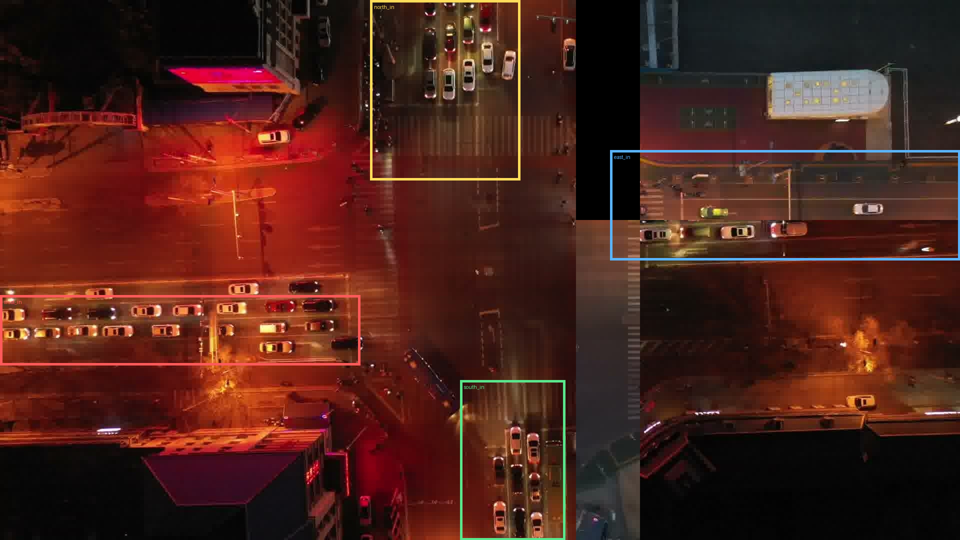

In [2]:
def representative_mosaic(frame_id=None):
    if frame_id is None:
        tile_counts = image_df.groupby("frame_id").size().sort_values(ascending=False)
        frame_id = int(tile_counts.index[0])
    subset = image_df[image_df["frame_id"] == frame_id].drop_duplicates(["crop_y", "crop_x"])
    canvas = Image.new("RGB", (1920, 1080), "black")
    for _, row in subset.iterrows():
        crop = Image.open(row["path"]).convert("RGB")
        canvas.paste(crop, (int(row["crop_x"]), int(row["crop_y"])))
    return frame_id, canvas

roi_frame_id, mosaic = representative_mosaic()
overlay = mosaic.copy()
draw = ImageDraw.Draw(overlay)
colors = {
    "west_in": (255, 90, 90),
    "east_in": (90, 180, 255),
    "north_in": (255, 220, 90),
    "south_in": (90, 230, 140),
}

for name, (x1, y1, x2, y2) in ROIS.items():
    draw.rectangle([x1, y1, x2, y2], outline=colors[name], width=5)
    draw.text((x1 + 8, y1 + 8), name, fill=colors[name])

roi_overlay_path = RESULTS_DIR / "task3_roi_overlay.jpg"
overlay.save(roi_overlay_path, quality=95)
print(f"ROI overlay saved to: {roi_overlay_path}")
display(overlay.resize((960, 540)))


## 3. Detection to Flow Time Series

The model runs on every crop image. Each detection is translated into global coordinates, duplicate detections from overlapping crops are merged with NMS per frame and class, then vehicle centers inside each ROI are counted.


In [3]:
def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return 0.0 if union <= 0 else inter / union

def nms_by_frame_class(detections, iou_threshold=0.5):
    kept = []
    grouped = defaultdict(list)
    for det in detections:
        grouped[(det["frame_id"], det["class_name"])].append(det)

    for _, group in grouped.items():
        group = sorted(group, key=lambda item: item["confidence"], reverse=True)
        while group:
            current = group.pop(0)
            kept.append(current)
            group = [
                item for item in group
                if iou_xyxy(current["box"], item["box"]) < iou_threshold
            ]
    return kept

def center_in_roi(box, roi):
    x1, y1, x2, y2 = box
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    rx1, ry1, rx2, ry2 = roi
    return rx1 <= cx <= rx2 and ry1 <= cy <= ry2

model = YOLO(str(MODEL_PATH))
paths = [str(path) for path in image_df["path"].tolist()]
metadata_by_path = {str(Path(row["path"]).resolve()): row for _, row in image_df.iterrows()}

def chunks(items, size):
    for start in range(0, len(items), size):
        yield items[start:start + size]

raw_detections = []
chunk_size = 64
for chunk_index, path_chunk in enumerate(chunks(paths, chunk_size), start=1):
    print(f"Predicting chunk {chunk_index}/{math.ceil(len(paths) / chunk_size)}", end="\r")
    for result in model.predict(source=path_chunk, imgsz=640, conf=0.25, batch=8, stream=True, verbose=False):
        row = metadata_by_path[str(Path(result.path).resolve())]
        frame_id = int(row["frame_id"])
        offset_x = float(row["crop_x"])
        offset_y = float(row["crop_y"])

        if result.boxes is None:
            continue

        for box, cls_id, conf in zip(result.boxes.xyxy.tolist(), result.boxes.cls.tolist(), result.boxes.conf.tolist()):
            class_name = model.names[int(cls_id)]
            if class_name not in ALL_COUNTED_CLASSES:
                continue

            gx1 = float(box[0]) + offset_x
            gy1 = float(box[1]) + offset_y
            gx2 = float(box[2]) + offset_x
            gy2 = float(box[3]) + offset_y
            raw_detections.append({
                "frame_id": frame_id,
                "class_name": class_name,
                "confidence": float(conf),
                "box": [gx1, gy1, gx2, gy2],
            })

detections = nms_by_frame_class(raw_detections, iou_threshold=0.5)
print()
print(f"Raw detections: {len(raw_detections)}")
print(f"Detections after NMS: {len(detections)}")



Raw detections: 174171
Detections after NMS: 136544


In [4]:
frame_ids = sorted(image_df["frame_id"].unique())
rows = []

detections_by_frame = defaultdict(list)
for det in detections:
    detections_by_frame[det["frame_id"]].append(det)

for frame_id in frame_ids:
    row = {"frame_id": int(frame_id)}
    for direction in ROIS:
        row[direction] = 0
    row["pedestrian_count"] = 0

    for det in detections_by_frame.get(frame_id, []):
        if det["class_name"] == "Pedestrian":
            if any(center_in_roi(det["box"], roi) for roi in ROIS.values()):
                row["pedestrian_count"] += 1
            continue

        if det["class_name"] not in VEHICLE_CLASSES:
            continue

        for direction, roi in ROIS.items():
            if center_in_roi(det["box"], roi):
                row[direction] += 1
                break

    row["total_flow"] = sum(row[direction] for direction in ROIS)
    rows.append(row)

flow_df = pd.DataFrame(rows).sort_values("frame_id").reset_index(drop=True)
flow_csv_path = RESULTS_DIR / "task3_flow_timeseries.csv"
flow_df.to_csv(flow_csv_path, index=False)

print(f"Flow time series saved to: {flow_csv_path}")
print(flow_df.head())
print("\nDirection totals:")
print(flow_df[[*ROIS.keys(), "total_flow", "pedestrian_count"]].sum())


Flow time series saved to: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_flow_timeseries.csv
   frame_id  west_in  east_in  north_in  south_in  pedestrian_count  \
0         1       22       13        24         1                50   
1         2        3        0         0         5                12   
2         5        1        0         0        10                 7   
3         6        4        6        12        11                30   
4         7        8       14        12        11                35   

   total_flow  
0          60  
1           8  
2          11  
3          33  
4          45  

Direction totals:
west_in             13428
east_in             15573
north_in             5740
south_in             2772
total_flow          37513
pedestrian_count    11700
dtype: int64


## 4. Traffic Pattern Analysis

The frame-level counts below show the estimated incoming flow by direction. The total flow is the sum of vehicle detections inside the four incoming-road ROIs.


Flow time-series plot saved to: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_flow_timeseries.png


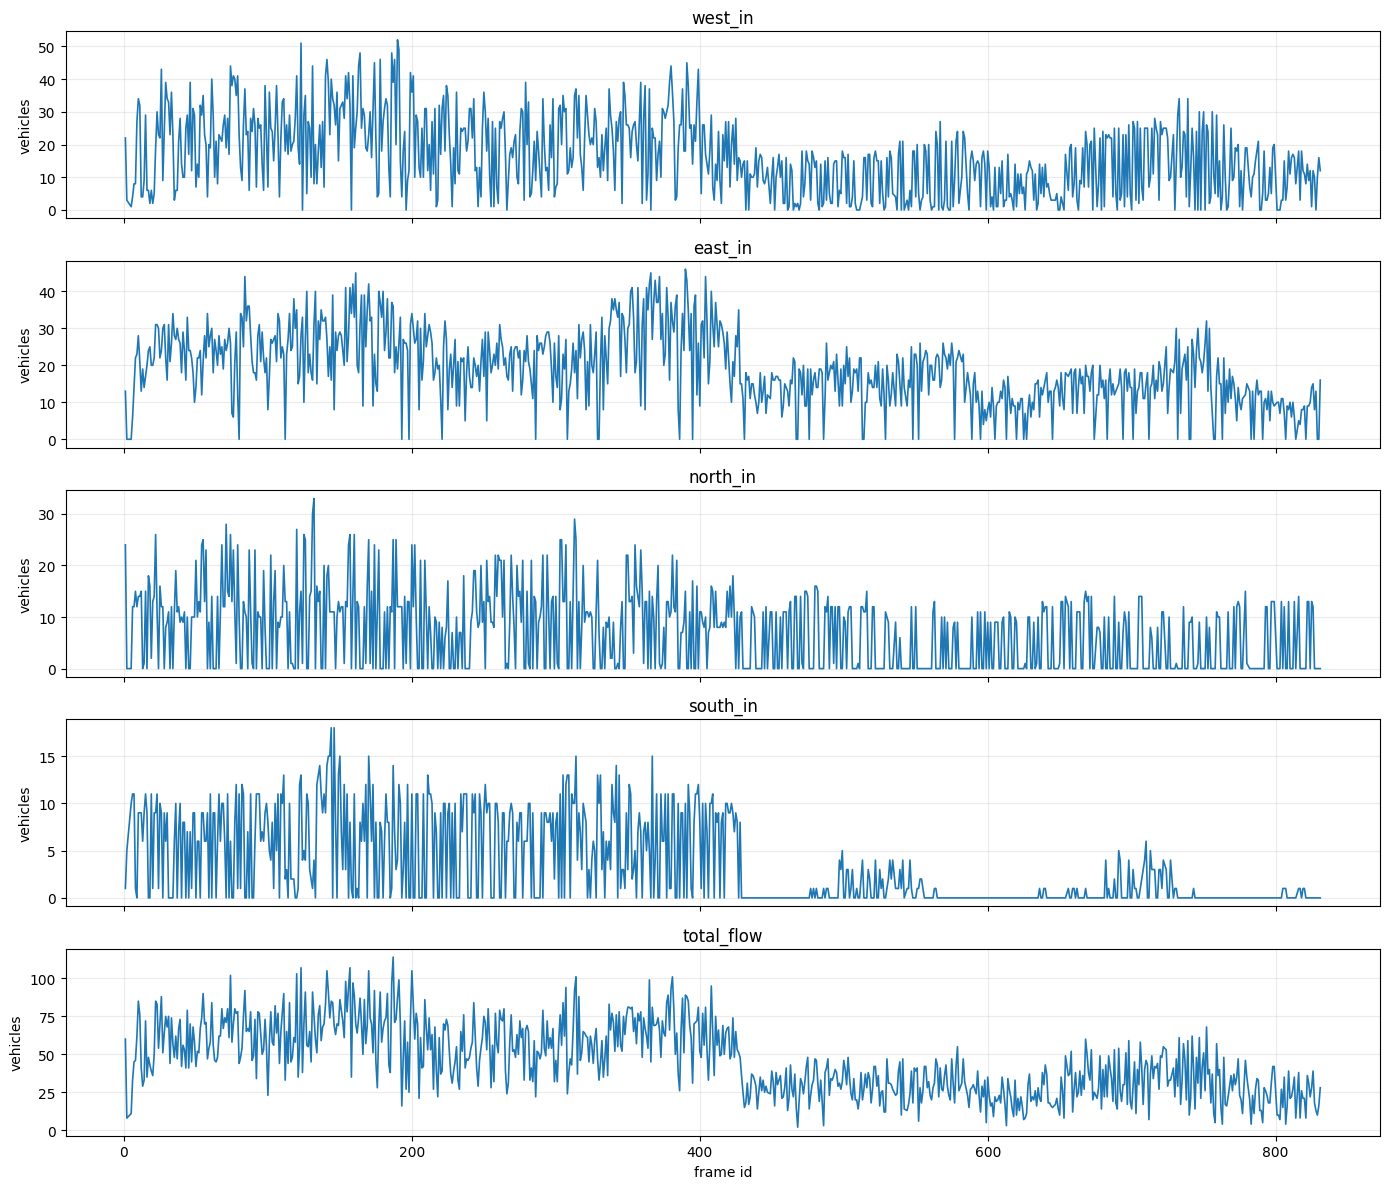

In [5]:
plot_columns = [*ROIS.keys(), "total_flow"]
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
for ax, column in zip(axes, plot_columns):
    ax.plot(flow_df["frame_id"], flow_df[column], linewidth=1.2)
    ax.set_title(column)
    ax.set_ylabel("vehicles")
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("frame id")
plt.tight_layout()

timeseries_plot_path = RESULTS_DIR / "task3_flow_timeseries.png"
fig.savefig(timeseries_plot_path, dpi=150)
print(f"Flow time-series plot saved to: {timeseries_plot_path}")
plt.show()


## 5. Forecasting and Baseline Comparison

Frame order is treated as evenly spaced time. The source video was sampled at one frame per second, so this notebook assumes one frame equals one second. Counts are aggregated into five-second bins to reduce detection noise while keeping enough points for evaluation. The two-hour forecast is a long extrapolation from about 13.6 minutes of sampled video, so it should be interpreted cautiously. The main model is SARIMAX/ARIMA and the baseline is a naive persistence forecast.


In [6]:
def aggregate_5sec(series_df):
    temp = series_df.copy()
    temp["time_second"] = np.arange(len(temp))
    temp["bin_5sec"] = temp["time_second"] // 5
    grouped = temp.groupby("bin_5sec")[[*ROIS.keys(), "total_flow"]].sum()
    grouped.index.name = "time_bin_5sec"
    return grouped

agg_df = aggregate_5sec(flow_df)
agg_csv_path = RESULTS_DIR / "task3_flow_timeseries_5sec.csv"
agg_df.to_csv(agg_csv_path)
print(f"5-second aggregated time series saved to: {agg_csv_path}")
print(agg_df.head())
print(f"Aggregated bins: {len(agg_df)}")


5-second aggregated time series saved to: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_flow_timeseries_5sec.csv
               west_in  east_in  north_in  south_in  total_flow
time_bin_5sec                                                  
0                   38       33        48        38         157
1                  105      107        70        28         310
2                   54       94        34        35         217
3                   34      118        71        30         253
4                  127      137        51        31         346
Aggregated bins: 164


In [7]:
def naive_persistence_forecast(train, test):
    history = list(train)
    preds = []
    for actual in test:
        pred = history[-1] if history else 0.0
        preds.append(pred)
        history.append(actual)
    return np.asarray(preds, dtype=float)

def fit_sarimax_forecast(train, steps):
    orders = [(1, 0, 1), (1, 0, 0), (0, 0, 1)]
    last_error = None
    for order in orders:
        try:
            model = SARIMAX(
                train,
                order=order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            result = model.fit(disp=False, maxiter=200)
            forecast = result.forecast(steps=steps)
            return np.maximum(np.asarray(forecast, dtype=float), 0.0), order
        except Exception as exc:
            last_error = exc

    fallback = np.repeat(float(train[-1]) if len(train) else 0.0, steps)
    print(f"SARIMAX fallback used: {last_error}")
    return fallback, "fallback_last_value"

def metric_row(series_name, model_name, y_true, y_pred, order=None):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    nonzero = y_true != 0
    mape = np.nan
    if nonzero.sum() >= max(3, int(0.2 * len(y_true))):
        mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100.0
    return {
        "series": series_name,
        "model": model_name,
        "order": str(order) if order is not None else "",
        "mae": mae,
        "rmse": rmse,
        "mape_percent": mape,
    }

forecast_columns = [*ROIS.keys(), "total_flow"]
metric_rows = []
forecast_outputs = {}
train_size = int(len(agg_df) * 0.8)
# 2 hours = 7200 seconds = 1440 five-second forecast bins.
horizon = 1440

for column in forecast_columns:
    series = agg_df[column].astype(float).to_numpy()
    train = series[:train_size]
    test = series[train_size:]

    sarimax_pred, order = fit_sarimax_forecast(train, len(test))
    naive_pred = naive_persistence_forecast(train, test)

    metric_rows.append(metric_row(column, "SARIMAX", test, sarimax_pred, order))
    metric_rows.append(metric_row(column, "Naive persistence", test, naive_pred))

    full_pred, future_order = fit_sarimax_forecast(series, horizon)
    future_baseline = np.repeat(float(series[-1]), horizon)
    forecast_outputs[column] = {
        "series": series,
        "test": test,
        "sarimax_test": sarimax_pred,
        "naive_test": naive_pred,
        "future_sarimax": full_pred,
        "future_naive": future_baseline,
        "order": future_order,
    }

metrics_df = pd.DataFrame(metric_rows)
metrics_path = RESULTS_DIR / "task3_forecast_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Forecast metrics saved to: {metrics_path}")
display(metrics_df)


Forecast metrics saved to: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_forecast_metrics.csv


,series,model,order,mae,rmse,mape_percent
0,west_in,SARIMAX,"(1, 0, 1)",29.446713,35.109556,46.966073
1,west_in,Naive persistence,,22.303030,26.692412,46.508227
2,east_in,SARIMAX,"(1, 0, 1)",28.987920,35.153461,70.063817
3,east_in,Naive persistence,,13.787879,18.316245,23.966295
4,north_in,SARIMAX,"(1, 0, 1)",13.715828,17.580823,61.674183
5,north_in,Naive persistence,,14.121212,17.480725,64.820202
6,south_in,SARIMAX,"(1, 0, 1)",5.444487,6.038331,95.179608
7,south_in,Naive persistence,,2.030303,3.000000,86.315708
8,total_flow,SARIMAX,"(1, 0, 1)",38.789251,46.288127,36.289425
9,total_flow,Naive persistence,,30.060606,36.133591,27.110375


## 6. Forecast Plots

The plots compare the held-out test period with SARIMAX and the naive persistence baseline. The continued forecast section projects the next two hours, interpreted as 1440 five-second bins.


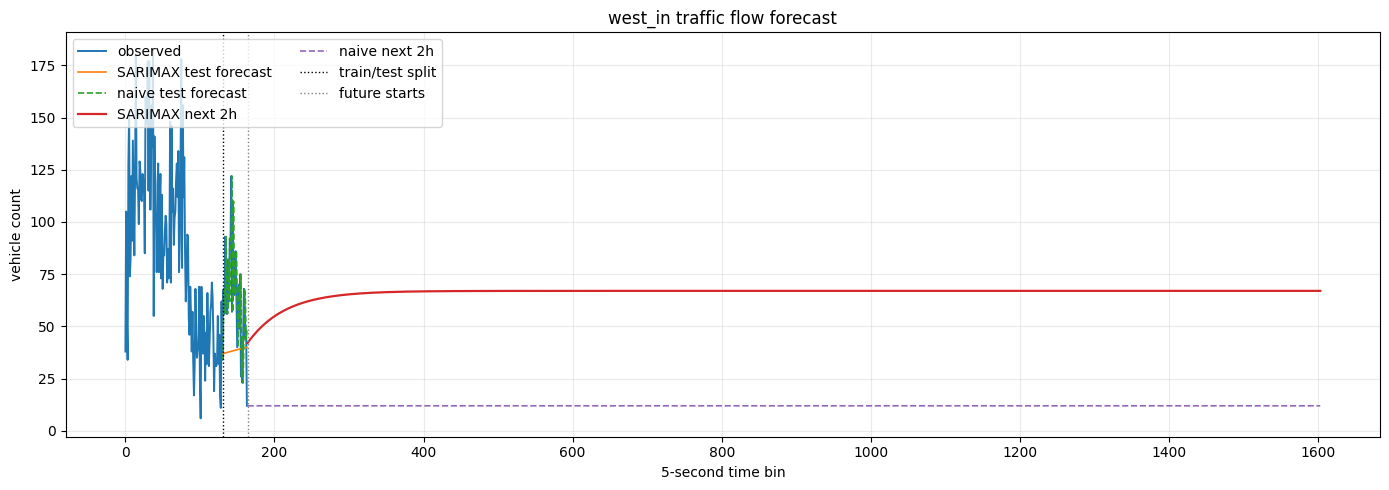

Saved forecast plot: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_forecast_plot_west_in.png


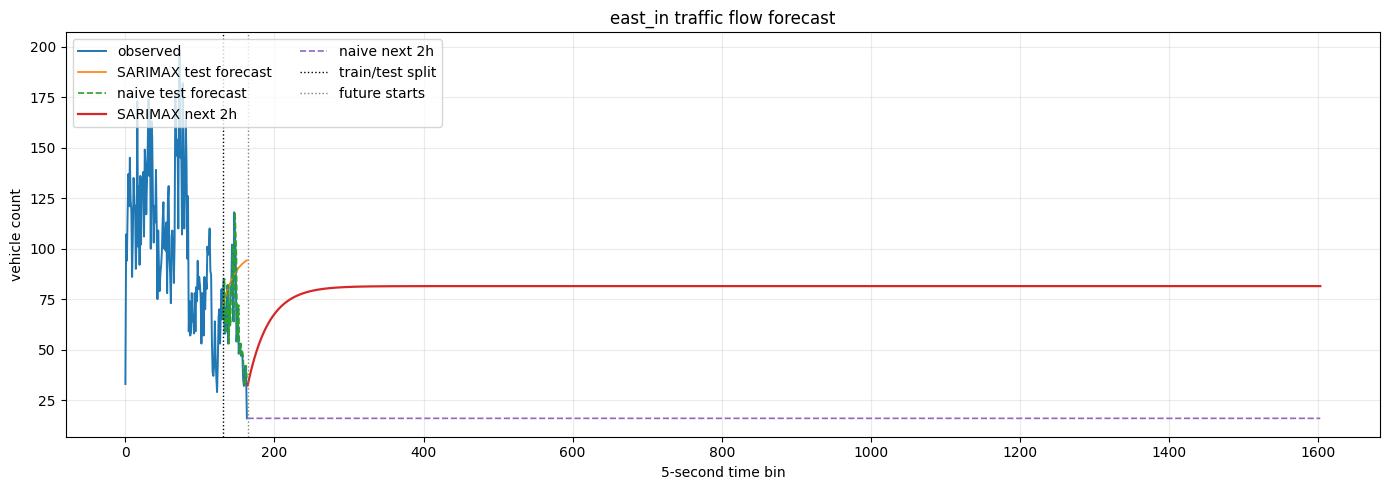

Saved forecast plot: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_forecast_plot_east_in.png


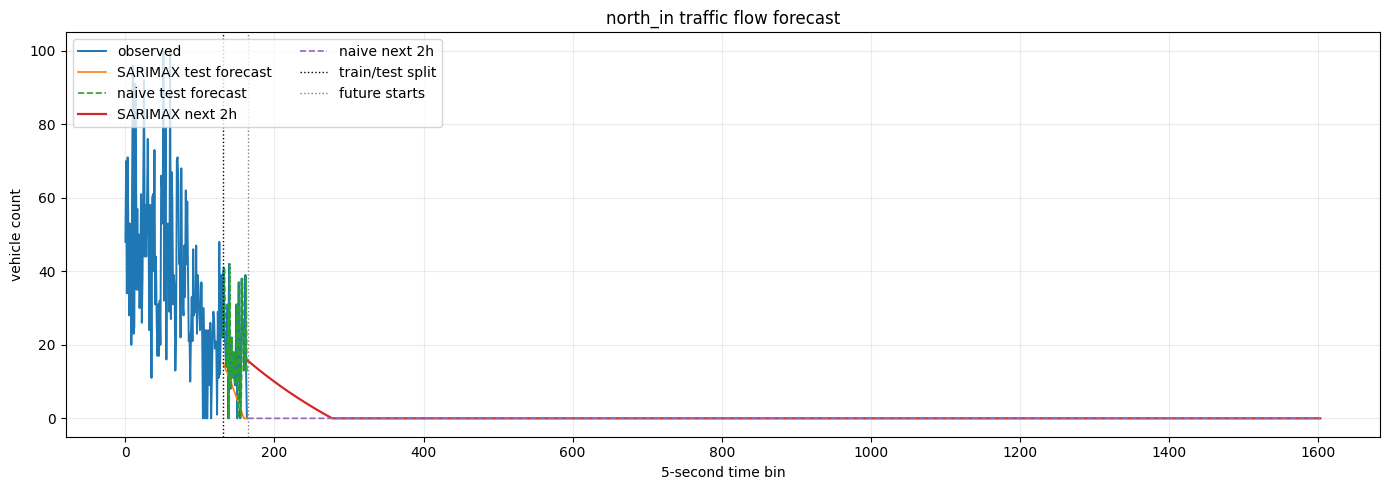

Saved forecast plot: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_forecast_plot_north_in.png


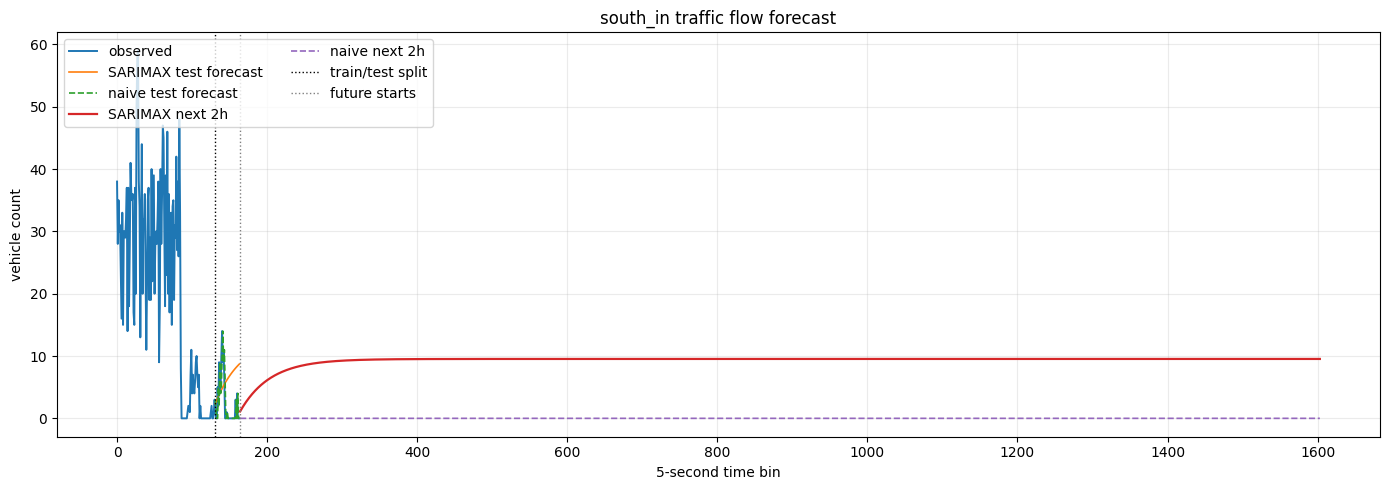

Saved forecast plot: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_forecast_plot_south_in.png


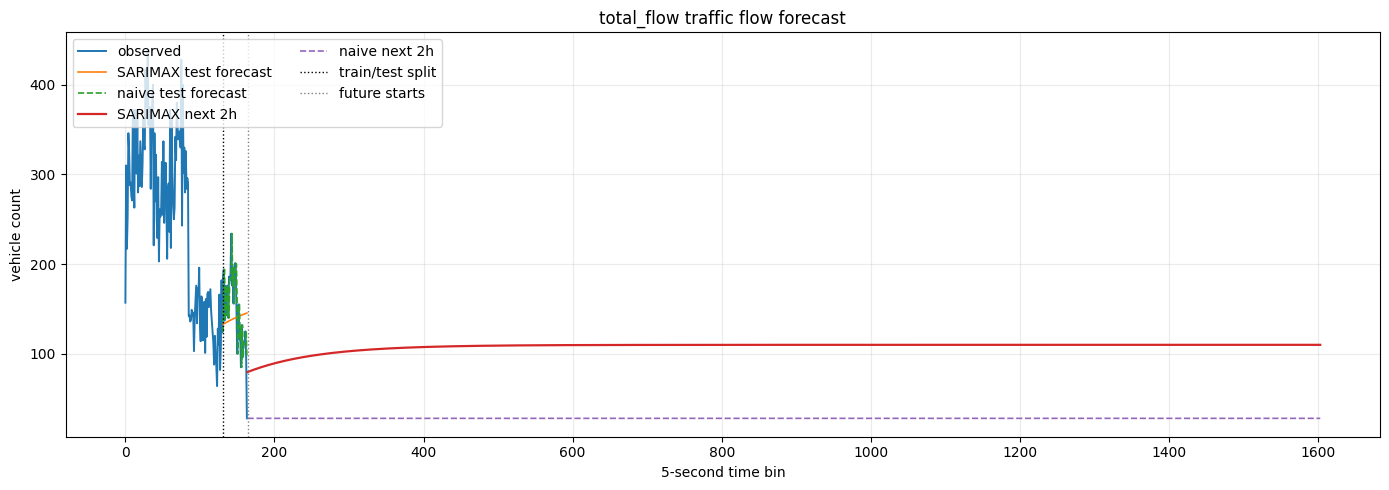

Saved forecast plot: C:\Users\Admin\Desktop\Project AdvanceAi\Project_AdvancedAI\Data\TrafficProject\results\task3_forecast_plot_total.png


In [8]:
def plot_forecast(column, output_path):
    out = forecast_outputs[column]
    series = out["series"]
    x = np.arange(len(series))
    test_x = np.arange(train_size, len(series))
    future_x = np.arange(len(series), len(series) + horizon)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(x, series, label="observed", linewidth=1.4)
    ax.plot(test_x, out["sarimax_test"], label="SARIMAX test forecast", linewidth=1.2)
    ax.plot(test_x, out["naive_test"], label="naive test forecast", linewidth=1.2, linestyle="--")
    ax.plot(future_x, out["future_sarimax"], label="SARIMAX next 2h", linewidth=1.6)
    ax.plot(future_x, out["future_naive"], label="naive next 2h", linewidth=1.2, linestyle="--")
    ax.axvline(train_size, color="black", linestyle=":", linewidth=1, label="train/test split")
    ax.axvline(len(series), color="gray", linestyle=":", linewidth=1, label="future starts")
    ax.set_title(f"{column} traffic flow forecast")
    ax.set_xlabel("5-second time bin")
    ax.set_ylabel("vehicle count")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", ncols=2)
    plt.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.show()

for column in forecast_columns:
    suffix = "total" if column == "total_flow" else column
    output_path = RESULTS_DIR / f"task3_forecast_plot_{suffix}.png"
    plot_forecast(column, output_path)
    print(f"Saved forecast plot: {output_path}")


## Conclusion

The ROI-based detector counts create a directional traffic-flow time series for the intersection. SARIMAX is compared with a naive persistence baseline using MAE and RMSE. The saved CSV files and figures can be used directly in the project report to show traffic patterns, forecasting performance, and the next-two-hour traffic-flow projection.
